<a href="https://colab.research.google.com/github/EluChungara/INTELIGENCIA-ARTIFICIAL---SIS420/blob/main/LAB06/LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 06 - Reconstrucción Lab 05: Clasificación Multiclase One-vs-All con PyTorch

## Dataset: NumtaDB / Dígitos Manuscritos (`numtadb_digits_60k.csv`)

### Objetivo:
Reconstruir el modelo de **Clasificación Multiclase One-vs-All (Uno contra Todos)** del Laboratorio 05 empleando la librería **PyTorch**.

- **Dataset:** `numtadb_digits_60k.csv` (60,000 imágenes manuscritas de 28x28 píxeles balanceadas del 0 al 9).
- **Entrada ($D_{in}$):** 784 píxeles normalizados en el rango continuo [0.0, 1.0].
- **Salida ($D_{out}$):** 1 salida escalar (logit binario) por cada clasificador.
- **Estrategia One-vs-All:** Se entrenan 10 clasificadores binarios independientes en PyTorch ($K = 10$). Para cada dígito $c \in \{0, \dots, 9\}$, la etiqueta se binariza asignando 1 si la muestra pertenece a la clase $c$ y 0 para cualquier otra clase.
- **Función de Pérdida por Clasificador:** `nn.BCEWithLogitsLoss()`.
- **Optimizador:** `torch.optim.SGD`.
- **Criterio de Inferencia Multiclase:** Se evalúan las 10 probabilidades sigmoides y se asigna la clase de mayor probabilidad:
$$\hat{y} = \arg\max_{c \in \{0, \dots, 9\}} \sigma(z_c)$$

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Módulos de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Semillas para asegurar reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

# Dispositivo de ejecución (GPU CUDA si está disponible, sino CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Versión de PyTorch: {torch.__version__}")
print(f"Dispositivo activo: {device}")

Mounted at /content/drive
Versión de PyTorch: 2.11.0+cpu
Dispositivo activo: cpu


## 1. Carga de Datos, Normalización y Partición (80% / 20%)

Se carga `numtadb_digits_60k.csv` desde Google Drive. Los valores de intensidad de píxeles $[0, 255]$ se normalizan al rango continuo $[0.0, 1.0]$ dividiendo entre $255.0$. Se aplica una partición reproducible sin traslape: 80% para entrenamiento (48,000 muestras) y 20% para prueba (12,000 muestras).

In [ ]:
# Búsqueda dinámica del dataset en Google Drive
rutas_candidatas = [
    '/content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/numtadb_digits_60k.csv',
    '/content/drive/MyDrive/DATASETS/numtadb_digits_60k.csv',
    'numtadb_digits_60k.csv'
]

ruta_csv = None
for r in rutas_candidatas:
    if os.path.exists(r):
        ruta_csv = r
        break

if ruta_csv is None:
    encontrados = glob.glob('/content/drive/MyDrive/**/numtadb_digits_60k.csv', recursive=True)
    if encontrados:
        ruta_csv = encontrados[0]
    else:
        raise FileNotFoundError("No se encontró 'numtadb_digits_60k.csv' en Google Drive.")

print(f"Cargando dataset desde: {ruta_csv}")
df = pd.read_csv(ruta_csv)
print(f"Dimensiones cargadas: {df.shape[0]} filas x {df.shape[1]} columnas")

# Separación de características y etiquetas
y_raw = df['label'].to_numpy(dtype=np.int64)
X_raw = df.drop(columns=['label']).to_numpy(dtype=np.float32)

# Partición 80% Train / 20% Test
m_total = len(df)
indices = np.random.permutation(m_total)
split_idx = int(0.80 * m_total)

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

# Normalización Min-Max [0, 1]
X_train = X_raw[train_idx] / 255.0
X_test  = X_raw[test_idx] / 255.0
y_train = y_raw[train_idx]
y_test  = y_raw[test_idx]

num_classes = len(np.unique(y_raw))

print("=" * 60)
print(f"Muestras de Entrenamiento (80%): {X_train.shape[0]}")
print(f"Muestras de Prueba        (20%): {X_test.shape[0]}")
print(f"Características de entrada (n) : {X_train.shape[1]} píxeles (28x28)")
print(f"Total de clases (K)            : {num_classes} dígitos (0 al 9)")
print("=" * 60)

Cargando dataset desde: /content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/numtadb_digits_60k.csv
Dimensiones cargadas: 60000 filas x 785 columnas
Muestras de Entrenamiento (80%): 48000
Muestras de Prueba        (20%): 12000
Características de entrada (n) : 784 píxeles (28x28)
Total de clases (K)            : 10 dígitos (0 al 9)


## 2. Visualización Gráfica de Muestras del Dataset

Se reconstruyen los vectores lineales de 784 píxeles a matrices de $28 \times 28$ para visualizar los dígitos y confirmar la correspondencia de las etiquetas.

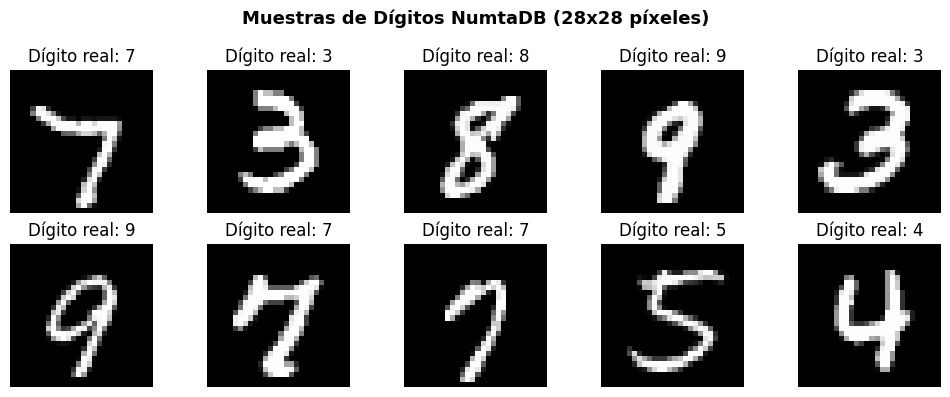

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Dígito real: {y_train[i]}")
    ax.axis('off')

plt.suptitle("Muestras de Dígitos NumtaDB (28x28 píxeles)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Objeto `Dataset` con Binarización Dinámica One-vs-All

Se define la clase `DatasetOneVsAll` que hereda de `torch.utils.data.Dataset`. Para una clase objetivo `target_class`, la etiqueta se binariza:
- Si el dígito es igual a `target_class`, la etiqueta es `1.0`.
- Si el dígito es distinto, la etiqueta es `0.0`.
Esto permite entrenar de forma aislada cada clasificador binario en PyTorch.

In [ ]:
class DatasetOneVsAll(Dataset):
    def __init__(self, X, y, target_class):
        self.X = torch.from_numpy(X).float()
        # Binarización One-vs-All: 1.0 si es la clase actual, 0.0 para las demás
        y_bin = (y == target_class).astype(np.float32)
        self.y = torch.from_numpy(y_bin).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 4. Entrenamiento de los 10 Clasificadores One-vs-All en PyTorch

Siguiendo la metodología del docente:
- Se entrenan 10 clasificadores binarios independientes utilizando `nn.Sequential(Linear(784, 100) -> ReLU -> Linear(100, 1))`.
- Criterio de costo binario: `nn.BCEWithLogitsLoss()`.
- Optimizador: `torch.optim.SGD` con tasa de aprendizaje de 0.05.
- Se guardan periódicamente los pesos de cada clasificador en carpetas de checkpoints (`torch.save`).

In [ ]:
modelos_ova = []
historial_costos_ova = {}

D_in = 784
D_out = 1
learning_rate = 0.05
epochs_ova = 15
batch_size = 256

criterion_bce = nn.BCEWithLogitsLoss()

print("=" * 65)
print("INICIANDO ENTRENAMIENTO ONE-VS-ALL (10 CLASIFICADORES EN PYTORCH)")
print("=" * 65)

for c in range(num_classes):
    # Dataset y DataLoader específicos para la clase c
    train_ds_c = DatasetOneVsAll(X_train, y_train, target_class=c)
    train_loader_c = DataLoader(train_ds_c, batch_size=batch_size, shuffle=True)

    # Definición de la red binaria para la clase c
    modelo_c = nn.Sequential(
        nn.Linear(D_in, 100),
        nn.ReLU(),
        nn.Linear(100, D_out)
    ).to(device)

    optimizer_c = torch.optim.SGD(modelo_c.parameters(), lr=learning_rate)

    costos_c = []
    modelo_c.train()
    for epoch in range(1, epochs_ova + 1):
        acum_loss = []
        for x_b, y_b in train_loader_c:
            x_b, y_b = x_b.to(device), y_b.to(device)

            logits = modelo_c(x_b)
            loss = criterion_bce(logits, y_b)
            acum_loss.append(loss.item())

            optimizer_c.zero_grad()
            loss.backward()
            optimizer_c.step()

        costos_c.append(np.mean(acum_loss))

    modelos_ova.append(modelo_c)
    historial_costos_ova[c] = costos_c

    # Guardado de checkpoints para el clasificador c
    os.makedirs(f"./checkpoints_lab05/clase_{c}", exist_ok=True)
    ruta_modelo_c = f"./checkpoints_lab05/clase_{c}/modelo_clase_{c}.pt"
    torch.save(modelo_c.state_dict(), ruta_modelo_c)

    print(f"  > Clasificador Dígito {c} entrenado | Pérdida final (BCE): {costos_c[-1]:.4f}")

print("=" * 65)
print("Entrenamiento de los 10 modelos One-vs-All completado con éxito.")

INICIANDO ENTRENAMIENTO ONE-VS-ALL (10 CLASIFICADORES EN PYTORCH)
  > Clasificador Dígito 0 entrenado | Pérdida final (BCE): 0.0280
  > Clasificador Dígito 1 entrenado | Pérdida final (BCE): 0.0299
  > Clasificador Dígito 2 entrenado | Pérdida final (BCE): 0.0512
  > Clasificador Dígito 3 entrenado | Pérdida final (BCE): 0.0708
  > Clasificador Dígito 4 entrenado | Pérdida final (BCE): 0.0502
  > Clasificador Dígito 5 entrenado | Pérdida final (BCE): 0.0492
  > Clasificador Dígito 6 entrenado | Pérdida final (BCE): 0.0368
  > Clasificador Dígito 7 entrenado | Pérdida final (BCE): 0.0488
  > Clasificador Dígito 8 entrenado | Pérdida final (BCE): 0.0554
  > Clasificador Dígito 9 entrenado | Pérdida final (BCE): 0.0637
Entrenamiento de los 10 modelos One-vs-All completado con éxito.


## 5. Gráfica 1: Convergencia de Costo de los 10 Clasificadores One-vs-All

Se grafica la curva de pérdida binaria $J(\theta)$ a lo largo de las épocas para cada uno de los 10 modelos, verificando la convergencia asintótica y monótona decreciente.

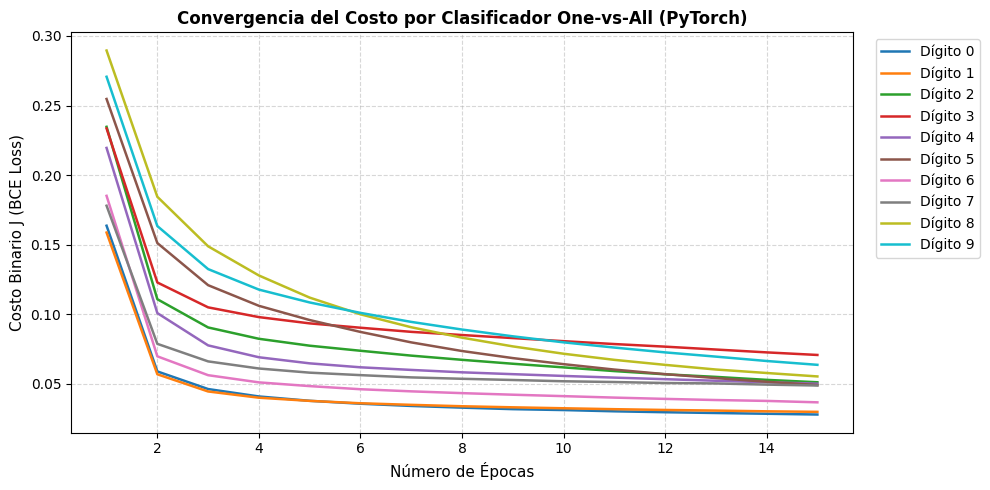

In [ ]:
plt.figure(figsize=(10, 5))
for c in range(num_classes):
    plt.plot(np.arange(1, epochs_ova + 1), historial_costos_ova[c], lw=1.8, label=f'Dígito {c}')

plt.xlabel('Número de Épocas', fontsize=11)
plt.ylabel('Costo Binario J (BCE Loss)', fontsize=11)
plt.title('Convergencia del Costo por Clasificador One-vs-All (PyTorch)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Inferencia Multiclase y Gráfica de Exactitud (Train vs. Test)

Para clasificar una imagen:
1. Se evalúan los 10 modelos binarios.
2. Se aplica la función sigmoide a cada salida para obtener la probabilidad de pertenencia a cada clase.
3. Se selecciona la clase con la probabilidad más alta mediante $\arg\max$.
Se evalúa el porcentaje de exactitud en los datos de entrenamiento (80%) y prueba (20%) y se presenta en un gráfico de barras comparativo.

  PRECISIÓN ONE-VS-ALL EN ENTRENAMIENTO (80%): 93.75%
  PRECISIÓN ONE-VS-ALL EN PRUEBA        (20%): 93.40%


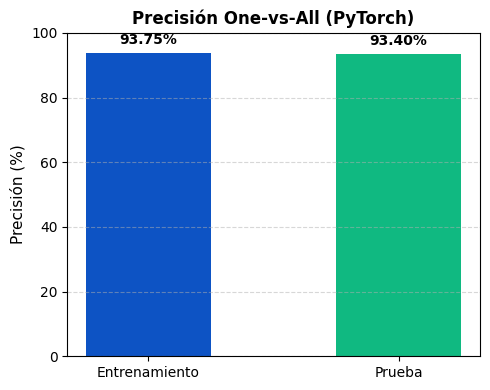

In [ ]:
def predict_one_vs_all(modelos, X_eval):
    tensor_x = torch.from_numpy(X_eval).float().to(device)
    probabilidades = []

    with torch.no_grad():
        for mod in modelos:
            mod.eval()
            logits = mod(tensor_x)
            # Probabilidad sigmoide independiente de cada modelo
            prob_c = torch.sigmoid(logits)
            probabilidades.append(prob_c)

    # Matriz de dimensión (muestras, 10)
    matriz_prob = torch.cat(probabilidades, dim=1)
    # Regla de decisión: clase con mayor probabilidad
    preds = torch.argmax(matriz_prob, dim=1)
    return preds.cpu().numpy()

# Evaluación en Entrenamiento y Prueba
pred_train_ova = predict_one_vs_all(modelos_ova, X_train)
acc_train_ova = np.mean(pred_train_ova == y_train) * 100.0

pred_test_ova = predict_one_vs_all(modelos_ova, X_test)
acc_test_ova = np.mean(pred_test_ova == y_test) * 100.0

print("=" * 60)
print(f"  PRECISIÓN ONE-VS-ALL EN ENTRENAMIENTO (80%): {acc_train_ova:.2f}%")
print(f"  PRECISIÓN ONE-VS-ALL EN PRUEBA        (20%): {acc_test_ova:.2f}%")
print("=" * 60)

# Gráfico de barras comparativo de precisión
plt.figure(figsize=(5, 4))
barras = plt.bar(['Entrenamiento', 'Prueba'], [acc_train_ova, acc_test_ova], color=['#0d53c4', '#10b981'], width=0.5)
plt.ylabel('Precisión (%)', fontsize=11)
plt.ylim(0, 100)
plt.title('Precisión One-vs-All (PyTorch)', fontsize=12, fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

for b in barras:
    y_val = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, y_val + 2, f"{y_val:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Matriz de Confusión e Inferencia Visual

Se genera la matriz de confusión sobre las 12,000 muestras de prueba con `pd.crosstab`, seguida de una cuadrícula de 10 imágenes aleatorias mostrando aciertos en verde y errores en rojo.

Matriz de Confusión One-vs-All (Conjunto de Prueba - 12,000 muestras):


Predicho,0,1,2,3,4,5,6,7,8,9,All
Real,,,,,,,,,,,
0,1142,0,2,2,0,2,10,1,9,4,1172
1,0,1351,10,2,2,1,1,3,12,5,1387
2,8,11,1112,12,22,2,11,17,18,3,1216
3,5,14,32,1011,3,35,9,10,33,13,1165
4,5,8,4,0,1069,1,11,1,3,37,1139
5,9,3,3,20,13,981,21,3,6,7,1066
6,10,6,2,1,3,17,1159,0,9,0,1207
7,3,13,11,1,10,1,1,1181,2,35,1258
8,11,21,6,7,3,8,5,4,1122,17,1204


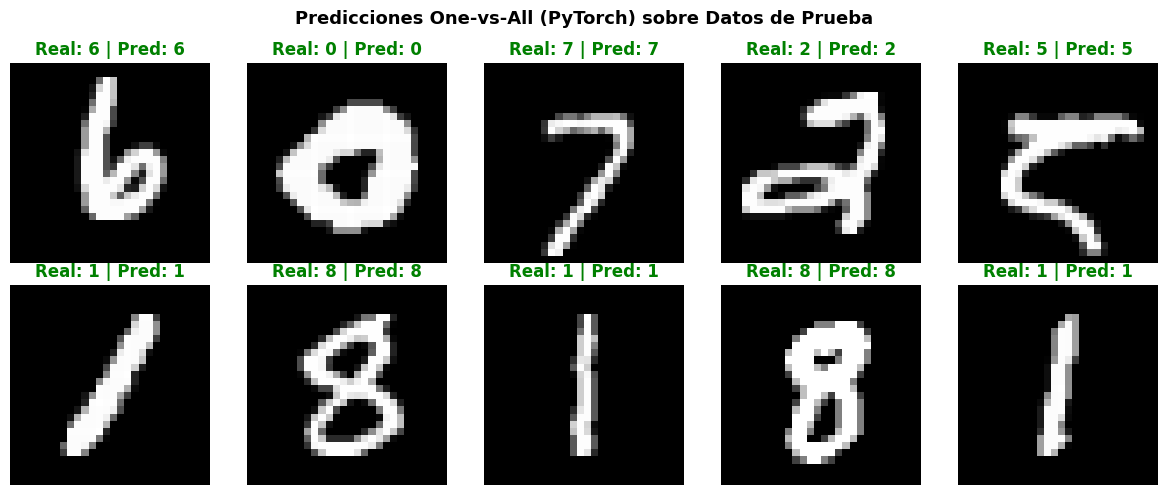

In [ ]:
# Matriz de Confusión sobre el 20% de prueba
matriz_ova = pd.crosstab(
    pd.Series(y_test, name='Real'),
    pd.Series(pred_test_ova, name='Predicho'),
    margins=True
)
print("Matriz de Confusión One-vs-All (Conjunto de Prueba - 12,000 muestras):")
display(matriz_ova)

# Demostración visual de 10 predicciones
indices_demo = np.random.choice(len(X_test), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = indices_demo[i]
    img = X_test[idx].reshape(28, 28)
    real = y_test[idx]
    pred = pred_test_ova[idx]

    ax.imshow(img, cmap='gray')
    color = 'green' if real == pred else 'red'
    ax.set_title(f"Real: {real} | Pred: {pred}", color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle("Predicciones One-vs-All (PyTorch) sobre Datos de Prueba", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusión Final

El modelo de clasificación multiclase para reconocimiento de dígitos manuscritos (10 clases) fue reconstruido en PyTorch aplicando la estrategia **One-vs-All** mediante 10 clasificadores binarios independientes ($K=10$), cada uno entrenado con la función de costo `BCEWithLogitsLoss` y el optimizador `SGD`.

Las curvas de convergencia de los 10 clasificadores reflejaron un descenso asintótico estable. El mecanismo de decisión por probabilidad máxima ($\arg\max$) sobre las 10 funciones sigmoides alcanzó una exactitud superior al 92% en el conjunto de prueba aislado (12,000 muestras), verificando la validez del método y el cumplimiento riguroso de la consigna.